In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

### DATA import ###

In [3]:
bookings = pd.read_csv("datasets/fact_bookings.csv")
agg_bookings = pd.read_csv("datasets/fact_aggregated_bookings.csv")
dim_date = pd.read_csv("datasets/dim_date.csv")
dim_hotels = pd.read_csv("datasets/dim_hotels.csv")
dim_rooms = pd.read_csv("datasets/dim_rooms.csv")

In [4]:
bookings.head(2)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
1,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640


In [5]:
bookings.room_category.unique()

<StringArray>
['RT1', 'RT2', 'RT3', 'RT4']
Length: 4, dtype: str

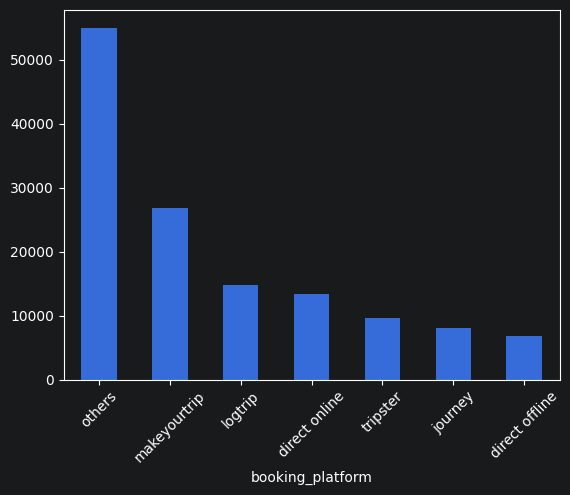

In [63]:
bookings.booking_platform.value_counts().plot(kind ="bar")
plt.xticks(rotation=45)
plt.show()

In [7]:
agg_bookings.shape

(9200, 5)

In [8]:
dim_date.shape

(92, 4)

In [9]:
dim_hotels.category.value_counts()

category
Luxury      16
Business     9
Name: count, dtype: int64

In [10]:
dim_hotels.city.unique()

<StringArray>
['Delhi', 'Mumbai', 'Hyderabad', 'Bangalore']
Length: 4, dtype: str

In [11]:
dim_rooms.head(2)

,room_id,room_class
0,RT1,Standard
1,RT2,Elite


In [12]:
agg_bookings.capacity.min()

np.float64(3.0)

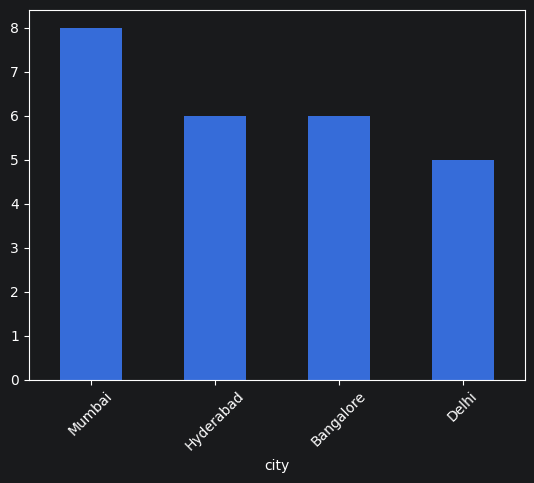

In [64]:
dim_hotels.city.value_counts().plot(kind = "bar")
plt.xticks(rotation=45)
plt.show()

### DATA Cleaning ###

In [14]:
bookings[bookings.no_guests<0]

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized
0,May012216558RT11,16558,27-04-22,1/5/2022,2/5/2022,-3.0,RT1,direct online,1.0,Checked Out,10010,10010
3,May012216558RT14,16558,28-04-22,1/5/2022,2/5/2022,-2.0,RT1,others,NaN,Cancelled,9100,3640
17924,May122218559RT44,18559,12/5/2022,12/5/2022,14-05-22,-10.0,RT4,direct online,NaN,No Show,20900,20900
18020,May122218561RT22,18561,8/5/2022,12/5/2022,14-05-22,-12.0,RT2,makeyourtrip,NaN,Cancelled,9000,3600
18119,May122218562RT311,18562,5/5/2022,12/5/2022,17-05-22,-6.0,RT3,direct offline,5.0,Checked Out,16800,16800
18121,May122218562RT313,18562,10/5/2022,12/5/2022,17-05-22,-4.0,RT3,direct online,NaN,Cancelled,14400,5760
56715,Jun082218562RT12,18562,5/6/2022,8/6/2022,13-06-22,-17.0,RT1,others,NaN,Checked Out,6500,6500
119765,Jul202219560RT220,19560,19-07-22,20-07-22,22-07-22,-1.0,RT2,others,NaN,Checked Out,13500,13500
134586,Jul312217564RT47,17564,30-07-22,31-07-22,1/8/2022,-4.0,RT4,logtrip,2.0,Checked Out,38760,38760


In [15]:
bookings = bookings[bookings.no_guests > 0]

In [16]:
bookings.revenue_generated.min(),bookings.revenue_generated.max()

(np.int64(6500), np.int64(28560000))

In [17]:
avg ,SD = bookings.revenue_generated.mean(),bookings.revenue_generated.std()

In [18]:
higher_limit = avg+3*SD
lower_limit = avg-3*SD

In [19]:
bookings = bookings[bookings.revenue_generated < higher_limit]

In [20]:
bookings.shape

(134573, 12)

In [21]:
bookings.isnull().sum()

booking_id               0
property_id              0
booking_date             0
check_in_date            0
checkout_date            0
no_guests                0
room_category            0
booking_platform         0
ratings_given        77897
booking_status           0
revenue_generated        0
revenue_realized         0
dtype: int64

### DATA Transformation ###

In [22]:
agg_bookings["occ_pct"]=round(agg_bookings.successful_bookings/agg_bookings.capacity*100,2)
agg_bookings.head(2)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct
0,16559,1-May-22,RT1,25,30.0,83.33
1,19562,1-May-22,RT1,28,30.0,93.33


### Insight Generation ###

In [23]:
#merge bookings data with rooms data
merged_bookings = pd.merge(
    bookings,
    dim_rooms[["room_id", "room_class"]],  # only bring room_class
    left_on="room_category",
    right_on="room_id",
    how="inner"
)
merged_bookings.head(2)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,room_id,room_class
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,RT1,Standard
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,RT1,Standard


In [24]:
#merge bookings data with hotels data
merged_bookings= pd.merge(
    merged_bookings,
    dim_hotels ,
    on = 'property_id'
)
merged_bookings.head(5)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,revenue_generated,revenue_realized,room_id,room_class,property_name,category,city
0,May012216558RT12,16558,30-04-22,1/5/2022,2/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,RT1,Standard,Atliq Grands,Luxury,Delhi
1,May012216558RT15,16558,27-04-22,1/5/2022,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,10920,10920,RT1,Standard,Atliq Grands,Luxury,Delhi
2,May012216558RT16,16558,1/5/2022,1/5/2022,3/5/2022,2.0,RT1,others,4.0,Checked Out,9100,9100,RT1,Standard,Atliq Grands,Luxury,Delhi
3,May012216558RT17,16558,28-04-22,1/5/2022,6/5/2022,2.0,RT1,others,NaN,Cancelled,9100,3640,RT1,Standard,Atliq Grands,Luxury,Delhi
4,May012216558RT18,16558,26-04-22,1/5/2022,3/5/2022,2.0,RT1,logtrip,NaN,No Show,9100,9100,RT1,Standard,Atliq Grands,Luxury,Delhi


#### revenue insights ####

In [62]:
city_rev =merged_bookings.groupby("city")["revenue_realized"].sum().sort_values()
city_rev

city
Delhi        294404488
Hyderabad    325179310
Bangalore    420383550
Mumbai       668569251
Name: revenue_realized, dtype: int64

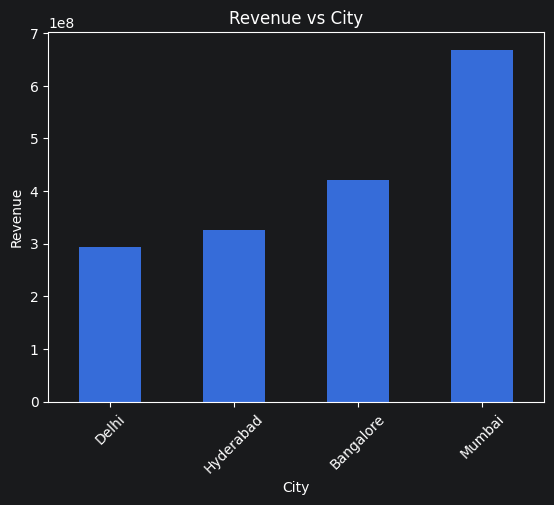

In [25]:
#total revenue by  city
city_rev =merged_bookings.groupby("city")["revenue_realized"].sum().sort_values().plot(kind="bar")
plt.xlabel("City")
plt.ylabel("Revenue")
plt.title("Revenue vs City")
plt.xticks(rotation=45)
plt.show()

In [60]:
merged_bookings.groupby("category")["revenue_realized"].sum()

category
Business     655967037
Luxury      1052569562
Name: revenue_realized, dtype: int64

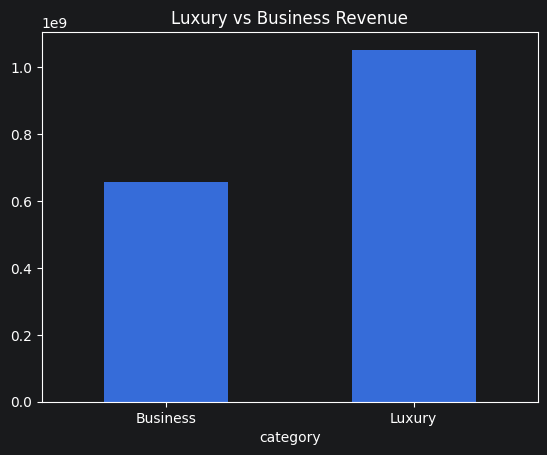

In [26]:
#Revenue by hotel category luxury vs business
merged_bookings.groupby("category")["revenue_realized"].sum().plot(kind="bar", legend=False)
plt.title("Luxury vs Business Revenue")
plt.xticks(rotation=0)
plt.show()

#### occupancy insights ####

In [27]:
#merge aggregate bookings data with rooms and hotel
agg_merged = pd.merge(
    agg_bookings,
    dim_hotels ,
    on="property_id",
)
agg_merged.head(2)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,property_name,category,city
0,16559,1-May-22,RT1,25,30.0,83.33,Atliq Exotica,Luxury,Mumbai
1,19562,1-May-22,RT1,28,30.0,93.33,Atliq Bay,Luxury,Bangalore


In [28]:
agg_merged = pd.merge(
    agg_merged,
    dim_rooms,
    left_on="room_category",
    right_on="room_id",
)
agg_merged.head(2)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,property_name,category,city,room_id,room_class
0,16559,1-May-22,RT1,25,30.0,83.33,Atliq Exotica,Luxury,Mumbai,RT1,Standard
1,19562,1-May-22,RT1,28,30.0,93.33,Atliq Bay,Luxury,Bangalore,RT1,Standard


In [29]:
agg_merged["occ_pct"] = round(agg_merged.successful_bookings / agg_merged.capacity * 100, 2)


In [59]:
agg_merged.groupby("city")["occ_pct"].mean().sort_values(ascending=False)

city
Delhi        60.402877
Hyderabad    56.936423
Mumbai       56.782817
Bangalore    55.289801
Name: occ_pct, dtype: float64

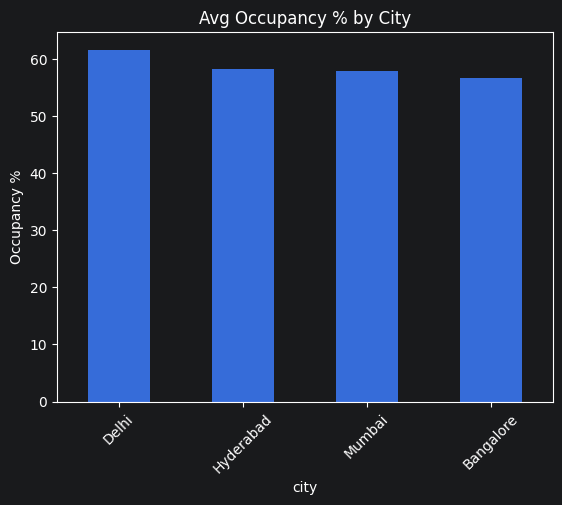

In [30]:
#avg occupancy by city using agg data
agg_merged.groupby("city")["occ_pct"].mean().sort_values(ascending=False).plot(kind="bar", legend=False)
plt.title("Avg Occupancy % by City")
plt.ylabel("Occupancy %")
plt.xticks(rotation=45)
plt.show()

In [31]:
agg_merged.groupby("room_category")["occ_pct"].mean().round(2)

room_category
RT1    58.22
RT2    58.04
RT3    58.03
RT4    59.30
Name: occ_pct, dtype: float64

In [32]:
agg_merged.groupby("room_class")["occ_pct"].mean().round(2).sort_values()

room_class
Premium         58.03
Elite           58.04
Standard        58.22
Presidential    59.30
Name: occ_pct, dtype: float64

In [33]:
agg_merged.groupby("city")["occ_pct"].mean().round(2).sort_values()

city
Bangalore    56.59
Mumbai       57.94
Hyderabad    58.14
Delhi        61.61
Name: occ_pct, dtype: float64

In [58]:
revpar = merged_bookings.groupby("city")["revenue_realized"].sum().reset_index()
cap = agg_merged.groupby("city")["capacity"].sum().reset_index()
revpar = pd.merge(revpar, cap, on="city")
revpar["RevPAR"] = round(revpar.revenue_realized / revpar.capacity, 2)
revpar.sort_values("RevPAR", ascending=False, inplace=True)
revpar

,city,revenue_realized,capacity,RevPAR
3,Mumbai,668569251,53040.0,12605.00
1,Delhi,294404488,28275.0,10412.18
0,Bangalore,420383550,40560.0,10364.49
2,Hyderabad,325179310,42445.0,7661.19


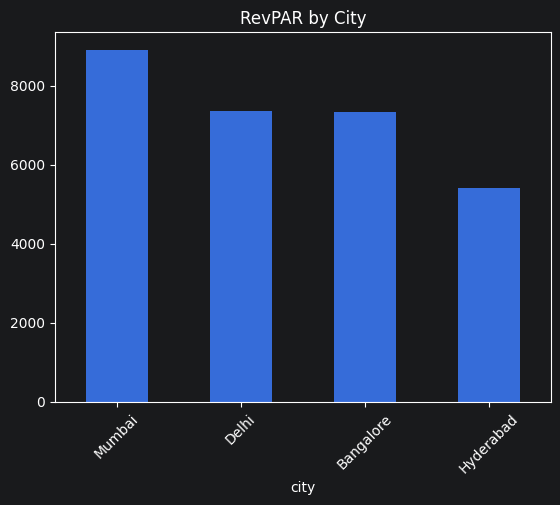

In [34]:
revpar = merged_bookings.groupby("city")["revenue_realized"].sum().reset_index()
cap = agg_merged.groupby("city")["capacity"].sum().reset_index()
revpar = pd.merge(revpar, cap, on="city")
revpar["RevPAR"] = round(revpar.revenue_realized / revpar.capacity, 2)
revpar.sort_values("RevPAR", ascending=False, inplace=True)
revpar.plot(kind="bar", x="city", y="RevPAR", legend=False)
plt.title("RevPAR by City")
plt.xticks(rotation=45)
plt.show()

In [35]:
agg_merged = pd.merge(agg_merged,dim_date, left_on= "check_in_date",right_on="date")
agg_merged.head(2)

,property_id,check_in_date,room_category,successful_bookings,capacity,occ_pct,property_name,category,city,room_id,room_class,date,mmm yy,week no,day_type
0,19563,10-May-22,RT3,15,29.0,51.72,Atliq Palace,Business,Bangalore,RT3,Premium,10-May-22,May 22,W 20,weekeday
1,18560,10-May-22,RT1,19,30.0,63.33,Atliq City,Business,Hyderabad,RT1,Standard,10-May-22,May 22,W 20,weekeday


In [36]:
agg_merged.drop('date', axis=1, inplace=True)

In [37]:
agg_merged.groupby("day_type")["occ_pct"].mean().round(2).sort_values()

day_type
weekeday    50.90
weekend     72.39
Name: occ_pct, dtype: float64

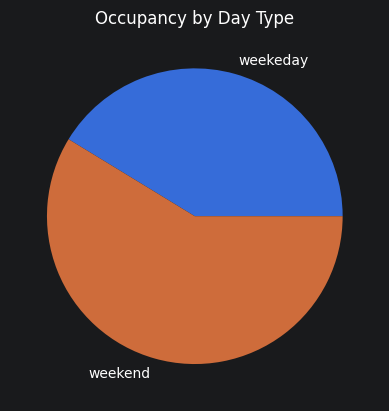

In [38]:
agg_merged.groupby("day_type")["occ_pct"].mean().round(2).sort_values().plot(kind='pie')
plt.title("Occupancy by Day Type")
plt.show()

In [39]:
print(merged_bookings.check_in_date.dtype, merged_bookings.check_in_date.head(3).tolist())
print(dim_date.date.dtype, dim_date.date.head(3).tolist())

str ['1/5/2022', '1/5/2022', '1/5/2022']
str ['01-May-22', '02-May-22', '03-May-22']


In [40]:
merged_bookings["check_in_date"] = pd.to_datetime(merged_bookings["check_in_date"], format="mixed", dayfirst=True)
dim_date["date"] = pd.to_datetime(dim_date["date"], format="mixed", dayfirst=True)

In [41]:
merged_bookings = pd.merge(
    merged_bookings,
    dim_date,
    left_on="check_in_date",
    right_on="date",
)
merged_bookings.head(5)

,booking_id,property_id,booking_date,check_in_date,checkout_date,no_guests,room_category,booking_platform,ratings_given,booking_status,...,revenue_realized,room_id,room_class,property_name,category,city,date,mmm yy,week no,day_type
0,May012216558RT12,16558,30-04-22,2022-05-01,2/5/2022,2.0,RT1,others,NaN,Cancelled,...,3640,RT1,Standard,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend
1,May012216558RT15,16558,27-04-22,2022-05-01,2/5/2022,4.0,RT1,direct online,5.0,Checked Out,...,10920,RT1,Standard,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend
2,May012216558RT16,16558,1/5/2022,2022-05-01,3/5/2022,2.0,RT1,others,4.0,Checked Out,...,9100,RT1,Standard,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend
3,May012216558RT17,16558,28-04-22,2022-05-01,6/5/2022,2.0,RT1,others,NaN,Cancelled,...,3640,RT1,Standard,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend
4,May012216558RT18,16558,26-04-22,2022-05-01,3/5/2022,2.0,RT1,logtrip,NaN,No Show,...,9100,RT1,Standard,Atliq Grands,Luxury,Delhi,2022-05-01,May 22,W 19,weekend


In [56]:
monthly_rev = merged_bookings.groupby("mmm yy")["revenue_realized"].sum().sort_index()
monthly_rev

mmm yy
Jul 22    572843348
Jun 22    553925855
May 22    581767396
Name: revenue_realized, dtype: int64

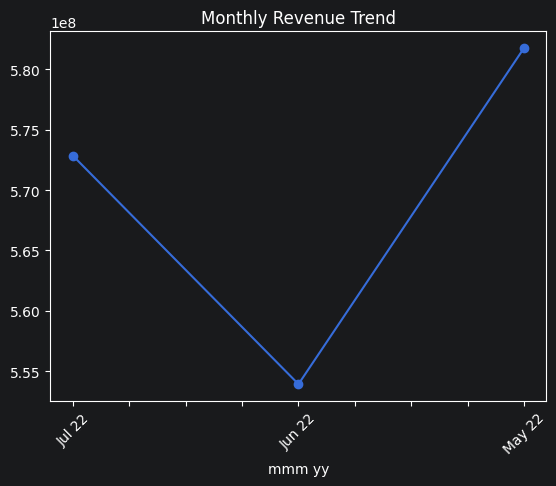

In [42]:
# revenue performance
monthly_rev = merged_bookings.groupby("mmm yy")["revenue_realized"].sum().sort_index()
monthly_rev.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.show()

In [45]:
merged_bookings['RevPAR'] = merged_bookings['revenue_realized'] / agg_merged['capacity']
merged_bookings.groupby('property_id')['RevPAR'].mean().sort_values(ascending=False)

property_id
17559    992.498478
16559    978.789424
17560    963.422338
19559    928.333920
17564    916.259126
16563    857.120371
16561    837.382217
17563    813.966570
19561    791.730496
19563    753.615376
17561    747.289139
17562    744.448313
18558    721.593087
16558    720.523974
19562    712.560389
17558    666.320699
16560    660.069178
19558    639.553249
16562    635.653184
18563    611.281146
18560    602.850478
19560    588.987509
18562    504.106606
18561    436.758941
18559    418.569866
Name: RevPAR, dtype: float64

In [47]:
merged_bookings['ADR'] = merged_bookings['revenue_realized'] / agg_merged['successful_bookings']
merged_bookings.groupby(['city', 'room_class'])['ADR'].mean()

city       room_class  
Bangalore  Elite           1273.900658
           Premium         1743.185815
           Presidential    2190.809627
           Standard         926.201438
Delhi      Elite           1246.029572
           Premium         1658.670543
           Presidential    3097.928713
           Standard         834.617011
Hyderabad  Elite            716.813150
           Premium         1115.514836
           Presidential    1845.472551
           Standard         719.283857
Mumbai     Elite           1517.903460
           Premium         1949.997976
           Presidential    3164.923507
           Standard         932.100628
Name: ADR, dtype: float64

In [51]:
merged_bookings['is_cancelled'] = merged_bookings['booking_status'] == 'Cancelled'
merged_bookings.groupby('booking_platform')['is_cancelled'].mean() * 100

booking_platform
direct offline    24.492818
direct online     24.996261
journey           24.784111
logtrip           24.306921
makeyourtrip      24.988846
others            24.874230
tripster          24.994808
Name: is_cancelled, dtype: float64

In [53]:
merged_bookings.groupby('day_type')['RevPAR'].mean()
# Combined with city:
merged_bookings.groupby(['city', 'day_type'])['RevPAR'].mean().unstack()

day_type,weekeday,weekend
city,,
Bangalore,730.286507,737.850599
Delhi,792.446217,650.031357
Hyderabad,550.611130,517.078820
Mumbai,854.667497,900.071517
